In [1]:
import math
import time
import numpy as np
import torch
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt
import random

## Initialize Database

In [ ]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    # 均值，标准差，输出形状
    return X, y.reshape((-1, 1))

In [ ]:
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
# feature输入值，label预测值

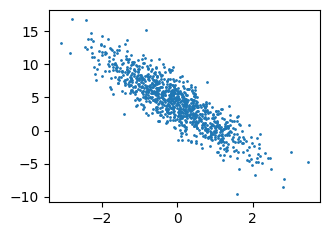

In [24]:
plt.figure(figsize = (3.5, 2.5))
plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)

## Read Database

In [5]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)] # 保证样本不被遗漏且不越界
        )
        yield features[batch_indices], labels[batch_indices] 

In [6]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-1.6661,  1.0423],
        [ 1.3722,  1.2013],
        [ 0.4516, -0.2623],
        [-0.3389,  0.0973],
        [-0.3413,  1.7029],
        [ 0.8301,  1.8711],
        [-2.1571,  0.8828],
        [ 0.4833, -0.8347],
        [ 0.7218,  2.6375],
        [ 1.7213, -1.4838]]) 
 tensor([[-2.6572],
        [ 2.8587],
        [ 5.9802],
        [ 3.2010],
        [-2.2763],
        [-0.5094],
        [-3.1325],
        [ 8.0032],
        [-3.3214],
        [12.6840]])


## Initialize Parameters

In [7]:
w = torch.normal(0, 0.01, size = (2, 1), requires_grad = True)
b = torch.zeros(1, requires_grad = True)

## Define the Model & Loss & Optimization

In [8]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

In [9]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [10]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## Train

In [11]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

In [12]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.033095
epoch 2, loss 0.000118
epoch 3, loss 0.000057


In [13]:
print(f'w loss: {true_w - w.reshape(true_w.shape)}')
print(f'b loss: {true_b - b}')

w loss: tensor([-0.0001,  0.0007], grad_fn=<SubBackward0>)
b loss: tensor([0.0007], grad_fn=<RsubBackward1>)


## Brief Implemention of Linear Regression

In [14]:
from torch.utils import data

In [15]:
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [16]:
def load_array(data_arrays, batch_size, is_train = True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle = is_train)

In [17]:
batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [18]:
next(iter(data_iter))

[tensor([[-0.8158, -1.6458],
         [-0.0659,  1.3814],
         [ 1.0140, -1.0936],
         [-0.4054, -1.7072],
         [-0.0821, -0.4381],
         [ 0.2506, -0.3461],
         [-0.1935, -0.5307],
         [ 0.5157, -1.2382],
         [ 1.4102,  1.3934],
         [-0.6893,  0.1758]]),
 tensor([[ 8.1744],
         [-0.6426],
         [ 9.9530],
         [ 9.1822],
         [ 5.5377],
         [ 5.8693],
         [ 5.6340],
         [ 9.4435],
         [ 2.2833],
         [ 2.2240]])]

In [19]:
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

In [20]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [21]:
# loss = nn.MSELoss()
loss = nn.SmoothL1Loss(beta = 1.0) # Huber

In [22]:
trainer = torch.optim.SGD(net.parameters(), lr = 0.03)

In [23]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        # print(w.grad)
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 2.237921
epoch 2, loss 0.393284
epoch 3, loss 0.001302
